# 03 Training Walkthrough

This notebook explains the next step after tokenizer and GPT:

`token ids -> GPT -> loss -> gradients -> optimizer step -> slightly better weights`

The goal is not to reproduce full nanochat pretraining. The real training script has distributed training, checkpointing, evaluation, learning-rate schedules, and custom optimizers.

Here we keep the core idea small enough to see:

- how a token stream becomes `idx` and `targets`
- how `model(idx, targets)` becomes a loss
- how `loss.backward()` creates gradients
- how `optimizer.step()` updates model weights
- how repeated steps can lower loss on a tiny toy document pattern

No dataset download is required for this notebook.

In [1]:
from pathlib import Path
import os
import sys

repo_root = Path.cwd()
if not ((repo_root / "nanochat").exists() and (repo_root / "pyproject.toml").exists()):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "nanochat").exists() and (candidate / "pyproject.toml").exists():
            repo_root = candidate
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str(repo_root / ".cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

missing = []
for module_name in ["torch", "matplotlib"]:
    try:
        __import__(module_name)
    except Exception:
        missing.append(module_name)

if missing:
    missing_str = ", ".join(missing)
    raise RuntimeError(
        f"Missing dependencies: {missing_str}\n"
        f"Current Python executable: {sys.executable}\n\n"
        "This usually means Jupyter opened the notebook on the wrong kernel.\n"
        "In Jupyter, switch to the `nanochat (.venv)` kernel and rerun this cell.\n\n"
        "If you have not installed that kernel yet, from the repo root run:\n"
        "  uv sync --extra cpu --group dev\n"
        "  source .venv/bin/activate\n"
        "  python -m ipykernel install --user --name nanochat --display-name 'nanochat (.venv)'"
    )

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from nanochat.common import COMPUTE_DTYPE
from nanochat.gpt import GPT, GPTConfig

torch.manual_seed(1337)

print(f"repo_root: {repo_root}")
print(f"python: {sys.executable}")
print(f"torch: {torch.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"compute dtype: {COMPUTE_DTYPE}")

repo_root: /Users/eugene/Developer/nanochat
python: /Users/eugene/Developer/nanochat/.venv/bin/python
torch: 2.9.1
matplotlib: 3.10.8
compute dtype: torch.float32


## Step 1. The training loop in one picture

After tokenizer and GPT, the central loop is:

```text
1. get token batch
2. split it into inputs and next-token targets
3. run GPT forward pass
4. compute cross-entropy loss
5. run backward pass to compute gradients
6. optimizer updates weights
7. repeat
```

In real nanochat, this is mainly spread across:

- `nanochat/dataset.py`: downloads/lists local parquet dataset shards
- `nanochat/dataloader.py`: reads parquet text and builds `x, y` token batches
- `nanochat/gpt.py`: turns `x, y` into loss
- `scripts/base_train.py`: runs backward pass and optimizer steps

The tiny version below keeps the same shape of idea, but uses a small in-memory toy document set instead of downloaded parquet files.

One important difference from many PyTorch tutorials: nanochat does **not** use `torch.utils.data.Dataset` plus `torch.utils.data.DataLoader`. It uses a custom generator that directly yields full token tensors.

## Step 2. `dataset.py` vs `dataloader.py`

Before thinking about `idx` and `targets`, separate the file responsibilities.

`nanochat/dataset.py` is about the files on disk:

```text
Hugging Face parquet shards
-> download shard_00000.parquet, shard_00001.parquet, ...
-> store them under base_data_climbmix/
-> list local parquet files when training starts
```

`nanochat/dataloader.py` is about model-ready tensors:

```text
local parquet files
-> read the text column
-> tokenizer.encode(...) turns text into token ids
-> pack token ids into row_buffer
-> create x/y tensors by shifting row_buffer
-> yield x, y for GPT training
```

So the handoff is file-based:

```text
dataset.py downloads/finds parquet files
dataloader.py reads those files and turns them into tensors
```

This is different from classic PyTorch tutorials where `Dataset` often owns individual examples and `DataLoader` batches them. In nanochat, the custom dataloader owns much more of the pipeline because language-model pretraining wants efficient document packing and fixed-length token batches.

## Step 3. What `dataloader.py` must produce: `x` and `y`

This section is teaching the **final product of `dataloader.py`**, not the download step.

By the time training calls the model, raw text is already gone. The real dataloader has already done this kind of work:

```text
read parquet text -> tokenizer.encode(...) -> token-id lists -> packed rows
```

Then it must create next-token prediction tensors.

In `dataloader.py`, the tensors are named:

```python
inputs, targets
```

In `base_train.py`, they are received as:

```python
x, y, dataloader_state_dict = next(train_loader)
```

In `gpt.py`, the same tensors enter `forward(...)` as:

```python
def forward(self, idx, targets=None, ...):
```

So these names refer to the same idea:

```text
inputs == x == idx
targets == y == targets
```

The code below uses tiny toy documents and a tiny fake tokenizer mapping so we can see the same shape of data without downloading real parquet shards.

In [2]:
# Tiny stand-in for parquet text documents.
# Real nanochat reads strings from the parquet `text` column.
toy_documents = [
    "a b c d e f g h",
    "d e f g h a b c",
    "a b c d e f g h",
    "d e f g h a b c",
]

# Tiny stand-in for a trained tokenizer vocabulary.
# Real nanochat uses RustBPETokenizer.encode(...), not this hand-written mapping.
toy_vocab = {
    "<bos>": 0,
    "a": 1,
    "b": 2,
    "c": 3,
    "d": 4,
    "e": 5,
    "f": 6,
    "g": 7,
    "h": 8,
}


def toy_tokenizer_encode(doc_batch, prepend=0):
    # Mirrors tokenizer.encode(doc_batch, prepend=bos_token) at a toy scale.
    token_lists = []
    for doc in doc_batch:
        token_lists.append([prepend] + [toy_vocab[word] for word in doc.split()])
    return token_lists


toy_token_lists = toy_tokenizer_encode(toy_documents, prepend=toy_vocab["<bos>"])


def make_toy_batch(batch_size=2, seq_len=8, offset=0):
    # Mirrors the final dataloader job: fill rows of length T + 1,
    # then shift each row into inputs and targets.
    row_capacity = seq_len + 1
    rows = []
    for row_idx in range(batch_size):
        doc_tokens = toy_token_lists[(offset + row_idx) % len(toy_token_lists)]
        assert len(doc_tokens) == row_capacity
        rows.append(torch.tensor(doc_tokens, dtype=torch.long))
    rows = torch.stack(rows)

    # This mirrors dataloader.py:
    #   inputs  = row_buffer[:, :-1]
    #   targets = row_buffer[:, 1:]
    idx = rows[:, :-1].contiguous()
    targets = rows[:, 1:].contiguous()
    return idx, targets, rows


idx, targets, rows = make_toy_batch(batch_size=2, seq_len=8, offset=0)

# Same tensors, different names in different files.
x = idx
y = targets

print("toy text documents:")
for doc in toy_documents[:2]:
    print(" ", repr(doc))
print()
print("toy_token_lists, like tokenizer.encode(...) would return:")
for tokens in toy_token_lists[:2]:
    print(" ", tokens)
print()
print("full packed rows, before shifting:")
print(rows)
print()
print("idx / x: model input tokens")
print(idx)
print(f"shape = {tuple(idx.shape)}, dtype = {idx.dtype}")
print()
print("targets / y: next tokens we want the model to predict")
print(targets)
print(f"shape = {tuple(targets.shape)}, dtype = {targets.dtype}")
print()
print("Name mapping:")
print("  dataloader.py yields: inputs, targets")
print("  base_train.py names:  x, y")
print("  gpt.py forward uses:  idx, targets")
print()
print("First row as prediction pairs:")
for current_token, next_token in zip(idx[0].tolist(), targets[0].tolist()):
    print(f"  given {current_token}, predict {next_token}")

toy text documents:
  'a b c d e f g h'
  'd e f g h a b c'

toy_token_lists, like tokenizer.encode(...) would return:
  [0, 1, 2, 3, 4, 5, 6, 7, 8]
  [0, 4, 5, 6, 7, 8, 1, 2, 3]

full packed rows, before shifting:
tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8],
        [0, 4, 5, 6, 7, 8, 1, 2, 3]])

idx / x: model input tokens
tensor([[0, 1, 2, 3, 4, 5, 6, 7],
        [0, 4, 5, 6, 7, 8, 1, 2]])
shape = (2, 8), dtype = torch.int64

targets / y: next tokens we want the model to predict
tensor([[1, 2, 3, 4, 5, 6, 7, 8],
        [4, 5, 6, 7, 8, 1, 2, 3]])
shape = (2, 8), dtype = torch.int64

Name mapping:
  dataloader.py yields: inputs, targets
  base_train.py names:  x, y
  gpt.py forward uses:  idx, targets

First row as prediction pairs:
  given 0, predict 1
  given 1, predict 2
  given 2, predict 3
  given 3, predict 4
  given 4, predict 5
  given 5, predict 6
  given 6, predict 7
  given 7, predict 8


## Step 4. Why nanochat does not use classic PyTorch `Dataset` / `DataLoader`

In many PyTorch projects, the flow looks like this:

```text
Dataset.__getitem__(i) -> one example
DataLoader -> collates many examples into a batch
training loop -> receives batch
```

nanochat does something more custom:

```text
parquet text files
-> read many text documents
-> tokenizer.encode(...) turns text into token-id lists
-> pack token-id lists into fixed-length rows
-> shift rows into inputs and targets
-> yield full tensors directly
```

So `nanochat/dataloader.py` is not a subclass of PyTorch `Dataset`. It is a generator. The training script uses it like this:

```python
train_loader = tokenizing_distributed_data_loader_with_state_bos_bestfit(...)
x, y, dataloader_state_dict = next(train_loader)
```

That can feel strange if you expect a classic PyTorch `DataLoader`, but the final result is familiar: it still produces tensors that go into the model.

## Step 5. The confusing `copy_` lines, with tiny tensors

The real dataloader builds a temporary `row_buffer` where every row has length `T + 1`. In the previous step, our `rows` tensor is playing that role.

Why `T + 1`? Because to train on `T` positions, we need one extra next token.

This is **not causal mask preparation**. This prepares input/target pairs for next-token prediction.

```text
row_buffer: [BOS, A, B, C, D]

inputs:     [BOS, A, B, C]
targets:    [A,   B, C, D]
```

So the model learns:

```text
given BOS -> predict A
given A   -> predict B
given B   -> predict C
given C   -> predict D
```

The real code is:

```python
cpu_inputs.copy_(row_buffer[:, :-1])
cpu_targets.copy_(row_buffer[:, 1:])
```

The causal mask is separate. It happens later inside attention with `causal=True`, so each position cannot look at future positions while predicting its target.

These `copy_` lines do not create dataset samples. They copy shifted slices into already-allocated tensors.

In [3]:
B = 2
T = 4

# Use the same toy token lists from Step 3, but shorten to T + 1 columns
# so the shifting is easier to inspect on screen.
toy_row_buffer = torch.tensor([
    toy_token_lists[0][:T + 1],
    toy_token_lists[1][:T + 1],
], dtype=torch.long)

# This mirrors nanochat's preallocated CPU buffer layout.
# First half stores inputs, second half stores targets.
toy_cpu_buffer = torch.empty(2 * B * T, dtype=torch.long)
toy_cpu_inputs = toy_cpu_buffer[:B * T].view(B, T)
toy_cpu_targets = toy_cpu_buffer[B * T:].view(B, T)

print("row_buffer, before shifting:")
print(toy_row_buffer)
print(f"shape = {tuple(toy_row_buffer.shape)}")
print()

print("row_buffer[:, :-1] means all rows, all tokens except the last:")
print(toy_row_buffer[:, :-1])
print()

print("row_buffer[:, 1:] means all rows, all tokens except the first:")
print(toy_row_buffer[:, 1:])
print()

# These are the exact two ideas from nanochat/dataloader.py.
toy_cpu_inputs.copy_(toy_row_buffer[:, :-1])
toy_cpu_targets.copy_(toy_row_buffer[:, 1:])

print("After copy_:")
print("toy_cpu_inputs:")
print(toy_cpu_inputs)
print("toy_cpu_targets:")
print(toy_cpu_targets)
print()

print("Prediction pairs from first row:")
for current_token, next_token in zip(toy_cpu_inputs[0].tolist(), toy_cpu_targets[0].tolist()):
    print(f"  given {current_token}, predict {next_token}")

row_buffer, before shifting:
tensor([[0, 1, 2, 3, 4],
        [0, 4, 5, 6, 7]])
shape = (2, 5)

row_buffer[:, :-1] means all rows, all tokens except the last:
tensor([[0, 1, 2, 3],
        [0, 4, 5, 6]])

row_buffer[:, 1:] means all rows, all tokens except the first:
tensor([[1, 2, 3, 4],
        [4, 5, 6, 7]])

After copy_:
toy_cpu_inputs:
tensor([[0, 1, 2, 3],
        [0, 4, 5, 6]])
toy_cpu_targets:
tensor([[1, 2, 3, 4],
        [4, 5, 6, 7]])

Prediction pairs from first row:
  given 0, predict 1
  given 1, predict 2
  given 2, predict 3
  given 3, predict 4


Important details:

- `row_buffer[:, :-1]` and `row_buffer[:, 1:]` are shifted views of the same packed rows.
- `copy_` means “copy values into this existing tensor in-place.” The underscore is the PyTorch convention for in-place operations.
- nanochat preallocates buffers so it does not create lots of new tensors every batch.
- After those copies, the real dataloader copies one flat CPU buffer to one flat GPU buffer, then yields `inputs, targets, state_dict`.

So the confusing line is just the next-token shift, written in a performance-aware way.

## Step 6. Build a tiny GPT

This is the same `GPT` class from `nanochat/gpt.py`, just with tiny dimensions.

One repo-specific constraint still matters: `smear_gate` reads the first 24 embedding channels, so `n_embd` must be at least 24.

In [4]:
cfg = GPTConfig(
    sequence_len=8,
    vocab_size=32,
    n_layer=2,
    n_head=4,
    n_kv_head=2,
    n_embd=24,
    window_pattern="L",
)

model = GPT(cfg)
model.init_weights()
model.train()

print(cfg)
print(f"parameter count: {sum(p.numel() for p in model.parameters()):,}")
print(f"device: {model.get_device()}")

Padding vocab_size from 32 to 64 for efficiency
GPTConfig(sequence_len=8, vocab_size=32, n_layer=2, n_head=4, n_kv_head=2, n_embd=24, window_pattern='L')
parameter count: 16,566
device: cpu


## Step 7. Forward pass: logits vs loss

There are two useful ways to call GPT:

```python
logits = model(idx)
loss = model(idx, targets)
```

When `targets` are missing, GPT returns logits.

When `targets` are provided, GPT computes cross-entropy loss internally and returns one scalar loss.

In [5]:
logits = model(idx)
loss = model(idx, targets)

print(f"logits.shape = {tuple(logits.shape)}")
print(f"loss.shape   = {tuple(loss.shape)}")
print(f"loss value   = {loss.item():.6f}")
print()
print("Interpret logits shape as:")
print("  batch size")
print("  sequence positions")
print("  score for each vocab token")
print()
print("For our batch:")
print(f"  batch size = {logits.shape[0]}")
print(f"  positions  = {logits.shape[1]}")
print(f"  vocab size = {logits.shape[2]}")

logits.shape = (2, 8, 32)
loss.shape   = ()
loss value   = 3.464591

Interpret logits shape as:
  batch size
  sequence positions
  score for each vocab token

For our batch:
  batch size = 2
  positions  = 8
  vocab size = 32


## Step 8. What loss means

For each position, logits are scores for every possible next token.

Cross-entropy asks:

```text
How much probability did the model assign to the correct next token?
```

High confidence on the correct token means lower loss.
Low confidence on the correct token means higher loss.

`GPT.forward(...)` does this internally with `F.cross_entropy(...)` when `targets` are provided.

In [6]:
manual_loss = F.cross_entropy(
    logits.reshape(-1, logits.size(-1)),
    targets.reshape(-1),
    ignore_index=-1,
)

print(f"loss from model(idx, targets): {loss.item():.6f}")
print(f"manual cross-entropy loss:    {manual_loss.item():.6f}")
print()
print("These match because model(idx, targets) is a convenience wrapper around the same idea.")

loss from model(idx, targets): 3.464591
manual cross-entropy loss:    3.464591

These match because model(idx, targets) is a convenience wrapper around the same idea.


## Step 9. Backward pass: loss creates gradients

Before `backward()`, parameters have values but no current gradients.

After:

```python
loss.backward()
```

PyTorch fills `.grad` tensors on model parameters. Those gradients say which direction each weight should move to reduce loss.

In [7]:
model.zero_grad(set_to_none=True)
loss = model(idx, targets)

print("Before backward:")
print(f"  lm_head has grad? {model.lm_head.weight.grad is not None}")
print(f"  wte has grad?     {model.transformer.wte.weight.grad is not None}")
print()

loss.backward()

checks = [
    ("token embedding table / wte", model.transformer.wte.weight),
    ("lm_head", model.lm_head.weight),
    ("first attention output projection", model.transformer.h[0].attn.c_proj.weight),
    ("smear_lambda", model.smear_lambda),
]

print("After backward:")
for name, param in checks:
    grad_norm = None if param.grad is None else param.grad.norm().item()
    print(f"  {name:34s} grad norm = {grad_norm:.8f}")

Before backward:
  lm_head has grad? False
  wte has grad?     False

After backward:
  token embedding table / wte        grad norm = 0.00210785
  lm_head                            grad norm = 1.58882701
  first attention output projection  grad norm = 0.00318456
  smear_lambda                       grad norm = 0.00078116


## Step 10. Optimizer step: gradients update weights

`backward()` only computes gradients. It does not update the model by itself.

The actual weight change happens here:

```python
optimizer.step()
```

The real `base_train.py` uses `model.setup_optimizer(...)`, which creates nanochat's custom parameter groups. For this learning notebook, plain `AdamW` is enough to show the core mechanism.

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

model.zero_grad(set_to_none=True)
loss_before = model(idx, targets)

tracked_weight_before = model.lm_head.weight.detach().clone()
loss_before.backward()
optimizer.step()
model.zero_grad(set_to_none=True)

tracked_weight_after = model.lm_head.weight.detach().clone()
weight_change = (tracked_weight_after - tracked_weight_before).norm().item()
loss_after_one_step = model(idx, targets).item()

print(f"loss before optimizer step: {loss_before.item():.6f}")
print(f"loss after one step:        {loss_after_one_step:.6f}")
print(f"lm_head weight change norm: {weight_change:.8f}")
print()
print("One step may improve a little, a lot, or even briefly get worse.")
print("Training is about many small updates, not one magic update.")

loss before optimizer step: 3.464591
loss after one step:        3.397821
lm_head weight change norm: 0.08313803

One step may improve a little, a lot, or even briefly get worse.
Training is about many small updates, not one magic update.


## Step 11. Mini training loop

Now we repeat the same operation many times on the toy document batches:

```text
make batch -> loss -> backward -> optimizer step -> zero gradients
```

Because the toy documents repeat a simple next-token pattern, the tiny model should quickly learn it.

Padding vocab_size from 32 to 64 for efficiency
first loss: 3.464591
last loss:  0.198944

A lower loss means the model is assigning more probability to the correct next tokens.


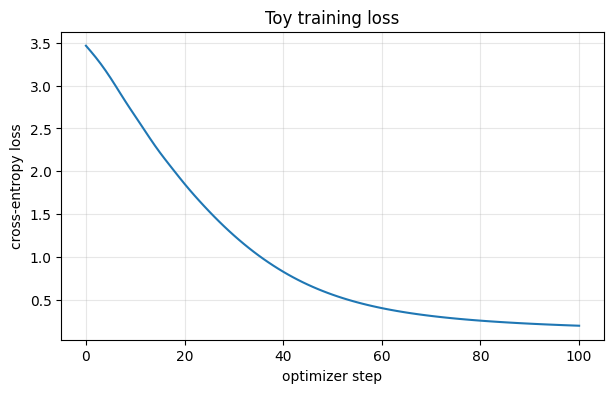

In [9]:
torch.manual_seed(1337)

train_model = GPT(cfg)
train_model.init_weights()
train_model.train()
train_optimizer = torch.optim.AdamW(train_model.parameters(), lr=3e-3)

losses = []
num_steps = 101

for step in range(num_steps):
    batch_idx, batch_targets, _ = make_toy_batch(batch_size=4, seq_len=8, offset=step)
    train_loss = train_model(batch_idx, batch_targets)
    losses.append(train_loss.item())

    train_optimizer.zero_grad(set_to_none=True)
    train_loss.backward()
    train_optimizer.step()

print(f"first loss: {losses[0]:.6f}")
print(f"last loss:  {losses[-1]:.6f}")
print()
print("A lower loss means the model is assigning more probability to the correct next tokens.")

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("Toy training loss")
plt.xlabel("optimizer step")
plt.ylabel("cross-entropy loss")
plt.grid(True, alpha=0.3)
plt.show()

## Step 12. How this maps to `scripts/base_train.py`

The real training script is bigger, but the core loop is the same.

Toy notebook:

```python
idx, targets, rows = make_toy_batch(...)
loss = model(idx, targets)
loss.backward()
optimizer.step()
model.zero_grad(set_to_none=True)
```

Real nanochat dataloader shift:

```python
cpu_inputs.copy_(row_buffer[:, :-1])
cpu_targets.copy_(row_buffer[:, 1:])
yield inputs, targets, state_dict
```

Real nanochat pretraining:

```python
x, y, dataloader_state_dict = next(train_loader)
loss = model(x, y)
loss.backward()
optimizer.step()
model.zero_grad(set_to_none=True)
```

The extra real-world pieces are important, but they are wrappers around this core:

- gradient accumulation: split a large batch into smaller micro-batches
- LR schedule: change learning rate over time
- custom optimizer groups: different parameter types get different optimizer settings
- eval loop: measure validation loss without updating weights
- checkpoints: save model/optimizer/dataloader state so training can resume
- distributed training: many GPUs process different batches together

## Step 13. What to learn after this

After this notebook, the next best files to read are:

- `nanochat/dataloader.py`: how real text documents are packed into `x, y`
- `scripts/base_train.py`: the full pretraining loop
- `nanochat/gpt.py` `setup_optimizer(...)`: how nanochat groups parameters for optimization
- `nanochat/loss_eval.py`: how validation loss is measured
- `scripts/chat_sft.py`: how the base model is trained to act more like a chat assistant

The most important bridge is now complete:

`tokenizer -> token ids -> GPT -> loss -> gradients -> optimizer step`

## Takeaways

- `dataset.py` downloads/finds local parquet files.
- `dataloader.py` reads those files and turns text into `x, y` tensors.
- nanochat uses a custom generator, not classic PyTorch `Dataset` / `DataLoader`.
- `idx` and `targets` are shifted versions of the same packed token row.
- `cpu_inputs.copy_(row_buffer[:, :-1])` copies all-but-last tokens into the input buffer.
- `cpu_targets.copy_(row_buffer[:, 1:])` copies all-but-first tokens into the target buffer.
- `model(idx)` returns logits; `model(idx, targets)` returns loss.
- Loss is the training signal: lower means better next-token predictions.
- `loss.backward()` computes gradients; `optimizer.step()` changes weights.
- Full nanochat training adds scale, speed, checkpointing, eval, and distributed execution around this same small loop.